# Query and Stack Imagery into a GIF Using stackstac and Dask

**Attribution**: This tutorial is developed based on the [example](https://stackstac.readthedocs.io/en/latest/examples/gif.html) provided in the stackstac documentation. 

We'll load all the [Landsat-8 (Collection 2, Level 2)](https://planetarycomputer.microsoft.com/dataset/landsat-8-c2-l2) data that's available from [Microsoft's Planetary Computer](https://planetarycomputer.microsoft.com/) over a small region on the coast of [Cape Cod](https://www.google.com/maps/place/Chatham,+MA/@41.7498076,-70.2026227,10.73z/data=!4m13!1m7!3m6!1s0x89fb15440149e94d:0x1f9c0efa001cb20b!2sCape+Cod!3b1!8m2!3d41.6687897!4d-70.2962408!3m4!1s0x89fb142168afbe53:0x714436ec7d485a53!8m2!3d41.6821432!4d-69.9597359), Massachusetts, USA.

Using nothing but standard xarray syntax, we'll mask cloudy pixels with the Landsat QA band and reduce the data down to biannual median composites. We will use Dask to make this much faster. 

[Animated](https://geogif.readthedocs.io/en/latest/) as a GIF, we can watch the coastline move over the years due to [longshore drift](https://en.wikipedia.org/wiki/Longshore_drift).

You can access this notebook on this [GitHub repo](https://github.com/HamedAlemo/dask-tutorial).

In [1]:
import dask
import pystac_client
import planetary_computer
import leafmap
import geogif
import stackstac
from rasterio.errors import RasterioIOError

Start your Dask cluster:

In [2]:
from dask.distributed import Client, LocalCluster
dask_cluster = LocalCluster()
dask_client = Client(dask_cluster)
print(dask_client.dashboard_link)

http://127.0.0.1:8787/status


2026-10-05 13:44:54,986 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/Users/hamed/git-repos/dask-tutorial/.pixi/envs/default/lib/python3.13/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "/Users/hamed/git-repos/dask-tutorial/.pixi/envs/default/lib/python3.13/site-packages/tornado/web.py", line 3546, in wrapper
    return method(self, *args, **kwargs)
  File "/Users/hamed/git-repos/dask-tutorial/.pixi/envs/default/lib/python3.13/site-packages/bokeh/server/views/ws.py", line 167, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure t

Interactively pick the area of interest from a map. Just move the map around and re-run all cells to generate the timeseries somewhere else!

In [3]:
import leafmap

In [4]:
m = leafmap.Map(center=[41.64933994767867, -69.94438630063088], zoom = 11, height = "600px", width="700px")
m

Map(center=[41.64933994767867, -69.94438630063088], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [5]:
aoi_bbox = (m.west, m.south, m.east, m.north)

## Search for STAC items

Use [pystac-client](https://github.com/stac-utils/pystac-client) to connect to Microsoft's STAC API endpoint and search for Landsat-8 scenes.

In [6]:
stac_catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier = planetary_computer.sign_inplace,
)

In [7]:
stac_search_results = stac_catalog.search(
    collections = ['landsat-c2-l2'],
    bbox = aoi_bbox,
    datetime = "2014-01-01/2026-01-01"
)

Load all the STAC items:

In [8]:
landsat_items = stac_search_results.item_collection()
print(f"{len(landsat_items)} scenes are returned from the STAC catalog query")

996 scenes are returned from the STAC catalog query


These are the footprints of all the items we'll use:

In [9]:
m.add_geojson(landsat_items.to_dict(), zoom_to_layer=True)
m

Map(bottom=195610.0, center=[41.64933994767867, -69.94438630063088], controls=(ZoomControl(options=['position'…

## Create an xarray with stacksatc

Let's first look at the metadata recoded in the item `properties`:

In [10]:
landsat_items[0].properties

{'gsd': 30,
 'created': '2026-01-05T09:21:23.823240Z',
 'sci:doi': '10.5066/P9OGBGM6',
 'datetime': '2025-12-30T15:21:20.611904Z',
 'platform': 'landsat-9',
 'proj:shape': [7911, 7801],
 'description': 'Landsat Collection 2 Level-2',
 'instruments': ['oli', 'tirs'],
 'eo:cloud_cover': 45.28,
 'proj:transform': [30.0, 0.0, 314985.0, 0.0, -30.0, 4741515.0],
 'view:off_nadir': 0,
 'landsat:wrs_row': '031',
 'landsat:scene_id': 'LC90110312025364LGN00',
 'landsat:wrs_path': '011',
 'landsat:wrs_type': '2',
 'view:sun_azimuth': 159.94669841,
 'landsat:correction': 'L2SP',
 'view:sun_elevation': 22.48823942,
 'landsat:cloud_cover_land': 17.7,
 'landsat:collection_number': '02',
 'landsat:collection_category': 'T1',
 'proj:code': 'EPSG:32619'}

In this case and as of Oct 2026, Microsoft Planetart Computer STAC catalog uses `'proj:code'` as the key value for recording item projection metadata. However, `stacstack` is still using the old key name `'proj:epsg'`. So, if we run the `stacstack` function it will fail as it cannot find the proper epsg value for the scene. We need to then add this key to the `properties` at the item level to make sure `stacstack` works properly: 

In [11]:
for item in landsat_items:
    item.properties["proj:epsg"] = int(item.properties["proj:code"].split(":")[-1])

Set `bounds_latlon=bbox` to automatically clip to our area of interest (instead of using the full footprints of the scenes).

In [12]:
%%time
landsat_stack = stackstac.stack(
    landsat_items,
    bounds_latlon = aoi_bbox,
    errors_as_nodata=(
        RasterioIOError("HTTP response code: 404"), 
        RasterioIOError(".*not recognized as being in a supported file format"),
    )
)
landsat_stack

CPU times: user 734 ms, sys: 32.2 ms, total: 766 ms
Wall time: 771 ms


<xarray.DataArray 'stackstac-95d7b64c28dc811deb8c77f1f54b99c5' (time: 996,
                                                                band: 22,
                                                                y: 1155, x: 1347)> Size: 273GB
dask.array<fetch_raster_window, shape=(996, 22, 1155, 1347), dtype=float64, chunksize=(1, 1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/32)
  * time                         (time) datetime64[ns] 8kB 2014-01-05T15:23:3...
    id                           (time) <U31 124kB 'LE07_L2SP_012031_20140105...
    instruments                  (time) object 8kB ['etm+'] ... ['oli', 'tirs']
    landsat:collection_category  (time) <U2 8kB 'T1' 'T2' 'T1' ... 'T1' 'T1'
    landsat:cloud_cover_land     (time) float64 8kB 48.0 100.0 ... 3.85 17.7
    view:sun_azimuth             (time) float64 8kB 158.2 159.2 ... 161.1 159.9
    ...                           ...
    landsat:collection_number    <U2 8B '02'
    proj:code                    <U10 40B 'EPSG:32619'
    landsat:correction           <U4 16B 'L2SP'
    view:off_nadir               int64 8B 0
    landsat:wrs_row              <U3 12B '031'
    epsg                         int64 8B 32619
Attributes:
    spec:        RasterSpec(epsg=32619, bounds=(401100.0, 4593960.0, 441510.0...
    crs:         epsg:32619
    transform:   | 30.00, 0.00, 401100.00|\n| 0.00,-30.00, 4628610.00|\n| 0.0...
    resolution:  30.0

And that's it for stackstac! Everything from here on is just standard xarray operations.

Band names are not trivial from the initial query:

In [13]:
landsat_stack.band 

<xarray.DataArray 'band' (band: 22)> Size: 1kB
array(['qa', 'red', 'blue', 'drad', 'emis', 'emsd', 'lwir', 'trad', 'urad',
       'atran', 'cdist', 'green', 'nir08', 'swir16', 'swir22', 'cloud_qa',
       'qa_pixel', 'qa_radsat', 'atmos_opacity', 'lwir11', 'coastal',
       'qa_aerosol'], dtype='<U13')
Coordinates: (12/17)
  * band                       (band) <U13 1kB 'qa' 'red' ... 'qa_aerosol'
    description                (band) object 176B 'Collection 2 Level-2 Quali...
    gsd                        (band) object 176B None None None ... None None
    raster:bands               (band) object 176B {'unit': 'kelvin', 'scale':...
    title                      (band) object 176B 'Surface Temperature Qualit...
    classification:bitfields   (band) object 176B None ... [{'name': 'fill', ...
    ...                         ...
    landsat:collection_number  <U2 8B '02'
    proj:code                  <U10 40B 'EPSG:32619'
    landsat:correction         <U4 16B 'L2SP'
    view:off_nadir             int64 8B 0
    landsat:wrs_row            <U3 12B '031'
    epsg                       int64 8B 32619

You can replace them using the `common_name` field:

In [14]:
landsat_stack = landsat_stack.assign_coords(band = landsat_stack.common_name.fillna(landsat_stack.band).rename("band"))
landsat_stack.band

<xarray.DataArray 'band' (band: 22)> Size: 176B
array(['qa', 'red', 'blue', 'drad', 'emis', 'emsd', 'lwir', 'trad', 'urad',
       'atran', 'cdist', 'green', 'nir08', 'swir16', 'swir22', 'cloud_qa',
       'qa_pixel', 'qa_radsat', 'atmos_opacity', 'lwir11', 'coastal',
       'qa_aerosol'], dtype=object)
Coordinates: (12/17)
  * band                       (band) object 176B 'qa' 'red' ... 'qa_aerosol'
    description                (band) object 176B 'Collection 2 Level-2 Quali...
    gsd                        (band) object 176B None None None ... None None
    raster:bands               (band) object 176B {'unit': 'kelvin', 'scale':...
    title                      (band) object 176B 'Surface Temperature Qualit...
    classification:bitfields   (band) object 176B None ... [{'name': 'fill', ...
    ...                         ...
    landsat:collection_number  <U2 8B '02'
    proj:code                  <U10 40B 'EPSG:32619'
    landsat:correction         <U4 16B 'L2SP'
    view:off_nadir             int64 8B 0
    landsat:wrs_row            <U3 12B '031'
    epsg                       int64 8B 32619

See how much input data there is for just RGB. This is the amount of data we'll end up processing

In [15]:
landsat_stack.sel(band=["red", "green", "blue"])

<xarray.DataArray 'stackstac-95d7b64c28dc811deb8c77f1f54b99c5' (time: 996,
                                                                band: 3,
                                                                y: 1155, x: 1347)> Size: 37GB
dask.array<getitem, shape=(996, 3, 1155, 1347), dtype=float64, chunksize=(1, 1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/32)
  * time                         (time) datetime64[ns] 8kB 2014-01-05T15:23:3...
    id                           (time) <U31 124kB 'LE07_L2SP_012031_20140105...
    instruments                  (time) object 8kB ['etm+'] ... ['oli', 'tirs']
    landsat:collection_category  (time) <U2 8kB 'T1' 'T2' 'T1' ... 'T1' 'T1'
    landsat:cloud_cover_land     (time) float64 8kB 48.0 100.0 ... 3.85 17.7
    view:sun_azimuth             (time) float64 8kB 158.2 159.2 ... 161.1 159.9
    ...                           ...
    landsat:collection_number    <U2 8B '02'
    proj:code                    <U10 40B 'EPSG:32619'
    landsat:correction           <U4 16B 'L2SP'
    view:off_nadir               int64 8B 0
    landsat:wrs_row              <U3 12B '031'
    epsg                         int64 8B 32619
Attributes:
    spec:        RasterSpec(epsg=32619, bounds=(401100.0, 4593960.0, 441510.0...
    crs:         epsg:32619
    transform:   | 30.00, 0.00, 401100.00|\n| 0.00,-30.00, 4628610.00|\n| 0.0...
    resolution:  30.0

## Mask cloudy pixels using the QA band

Use the bit values of the Landsat-8 QA band to mask out bad pixels. We'll mask pixels labeled as dilated cloud, cirrus, cloud, or cloud shadow. (By "mask", we mean just replacing those pixels with NaNs).

See page 14 on [this PDF](https://d9-wret.s3.us-west-2.amazonaws.com/assets/palladium/production/s3fs-public/media/files/LSDS-1619_Landsat-8-9-C2-L2-ScienceProductGuide-v4.pdf) for the data table describing which bit means what.

In [16]:
mask_bitfields = [1, 2, 3, 4]  # dilated cloud, cirrus, cloud, cloud shadow
bitmask = 0
for field in mask_bitfields:
    bitmask |= 1 << field

bin(bitmask)

'0b11110'

In [17]:
qa = landsat_stack.sel(band="qa_pixel").astype("uint16")
mask = qa & bitmask  # just look at those 4 bits

landsat_cloud_free_stack = landsat_stack.where(mask == 0)  # mask pixels where any one of those bits are set

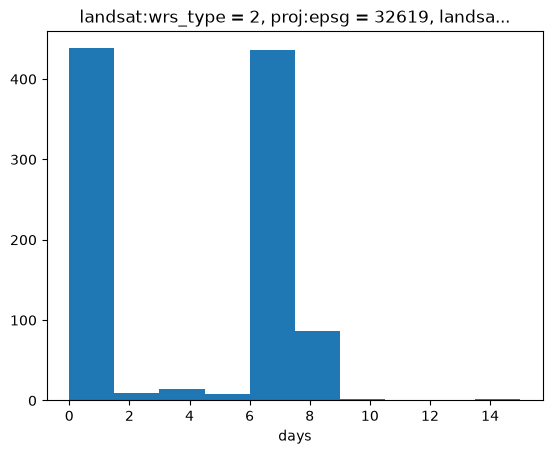

In [18]:
# What's the typical interval between scenes?
landsat_cloud_free_stack.time.diff("time").dt.days.plot.hist();

## Make biannual median composites

The Landsat-8 scenes appear to typically be 5-15 days apart. Let's composite that down to a 6-month interval.

Since the cloudy pixels we masked with NaNs will be ignored in the `median`, this should give us a decent cloud-free-ish image for each.

In [19]:
# Make biannual median composites (`2Q` means 2 quarters)
landsat_composites_stack = landsat_cloud_free_stack.resample(time="2Q").median("time")
landsat_composites_stack

<xarray.DataArray 'stackstac-95d7b64c28dc811deb8c77f1f54b99c5' (time: 25,
                                                                band: 22,
                                                                y: 1155, x: 1347)> Size: 7GB
dask.array<stack, shape=(25, 22, 1155, 1347), dtype=float64, chunksize=(1, 1, 498, 580), chunktype=numpy.ndarray>
Coordinates:
  * time                       (time) datetime64[ns] 200B 2014-03-31 ... 2026...
  * band                       (band) object 176B 'qa' 'red' ... 'qa_aerosol'
  * y                          (y) float64 9kB 4.629e+06 4.629e+06 ... 4.594e+06
  * x                          (x) float64 11kB 4.011e+05 ... 4.415e+05
    landsat:wrs_type           <U1 4B '2'
    proj:epsg                  int64 8B 32619
    landsat:collection_number  <U2 8B '02'
    proj:code                  <U10 40B 'EPSG:32619'
    landsat:correction         <U4 16B 'L2SP'
    view:off_nadir             int64 8B 0
    landsat:wrs_row            <U3 12B '031'
    epsg                       int64 8B 32619
Attributes:
    spec:        RasterSpec(epsg=32619, bounds=(401100.0, 4593960.0, 441510.0...
    crs:         epsg:32619
    transform:   | 30.00, 0.00, 401100.00|\n| 0.00,-30.00, 4628610.00|\n| 0.0...
    resolution:  30.0

Pick the red-green-blue bands to make a true-color image.

In [20]:
landsat_rgb_stack = landsat_composites_stack.sel(band=["red", "green", "blue"])
landsat_rgb_stack

<xarray.DataArray 'stackstac-95d7b64c28dc811deb8c77f1f54b99c5' (time: 25,
                                                                band: 3,
                                                                y: 1155, x: 1347)> Size: 933MB
dask.array<getitem, shape=(25, 3, 1155, 1347), dtype=float64, chunksize=(1, 1, 498, 580), chunktype=numpy.ndarray>
Coordinates:
  * time                       (time) datetime64[ns] 200B 2014-03-31 ... 2026...
  * band                       (band) object 24B 'red' 'green' 'blue'
  * y                          (y) float64 9kB 4.629e+06 4.629e+06 ... 4.594e+06
  * x                          (x) float64 11kB 4.011e+05 ... 4.415e+05
    landsat:wrs_type           <U1 4B '2'
    proj:epsg                  int64 8B 32619
    landsat:collection_number  <U2 8B '02'
    proj:code                  <U10 40B 'EPSG:32619'
    landsat:correction         <U4 16B 'L2SP'
    view:off_nadir             int64 8B 0
    landsat:wrs_row            <U3 12B '031'
    epsg                       int64 8B 32619
Attributes:
    spec:        RasterSpec(epsg=32619, bounds=(401100.0, 4593960.0, 441510.0...
    crs:         epsg:32619
    transform:   | 30.00, 0.00, 401100.00|\n| 0.00,-30.00, 4628610.00|\n| 0.0...
    resolution:  30.0

Some final cleanup to make a nicer-looking animation:

* Forward-fill any NaN pixels from the previous frame, to make the animation look less jumpy.
* Also skip the first frame, since its NaNs can't be filled from anywhere.

In [21]:
landsat_cleaned_stack = landsat_rgb_stack.ffill("time")[1:]

## Render the GIF

Use [GeoGIF](https://geogif.readthedocs.io/en/latest/) to turn the stack into an animation. We'll use [dgif](https://geogif.readthedocs.io/en/latest/api.html#dask-dgif) to render the GIF on the cluster, so there's less data to send back. (GIFs are a lot smaller than NumPy arrays!)

In [22]:
%%time
landsat_gif = geogif.dgif(landsat_cleaned_stack, fps=8).compute()

/Users/hamed/git-repos/dask-tutorial/.pixi/envs/default/lib/python3.13/site-packages/dask/array/chunk.py:288: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/Users/hamed/git-repos/dask-tutorial/.pixi/envs/default/lib/python3.13/site-packages/dask/array/chunk.py:288: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/Users/hamed/git-repos/dask-tutorial/.pixi/envs/default/lib/python3.13/site-packages/dask/array/chunk.py:288: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/Users/hamed/git-repos/dask-tutorial/.pixi/envs/default/lib/python3.13/site-packages/dask/array/chunk.py:288: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/Users/hamed/git-repos/dask-tutorial/.pixi/envs/default/lib/python3.13/site-packages/dask/array/chunk.py:288: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, 

CPU times: user 2min 46s, sys: 54.1 s, total: 3min 41s
Wall time: 13min 17s


In [23]:
# we turned ~34.6GiB of data into a 13.24MB GIF!
dask.utils.format_bytes(len(landsat_gif.data))

'13.24 MiB'

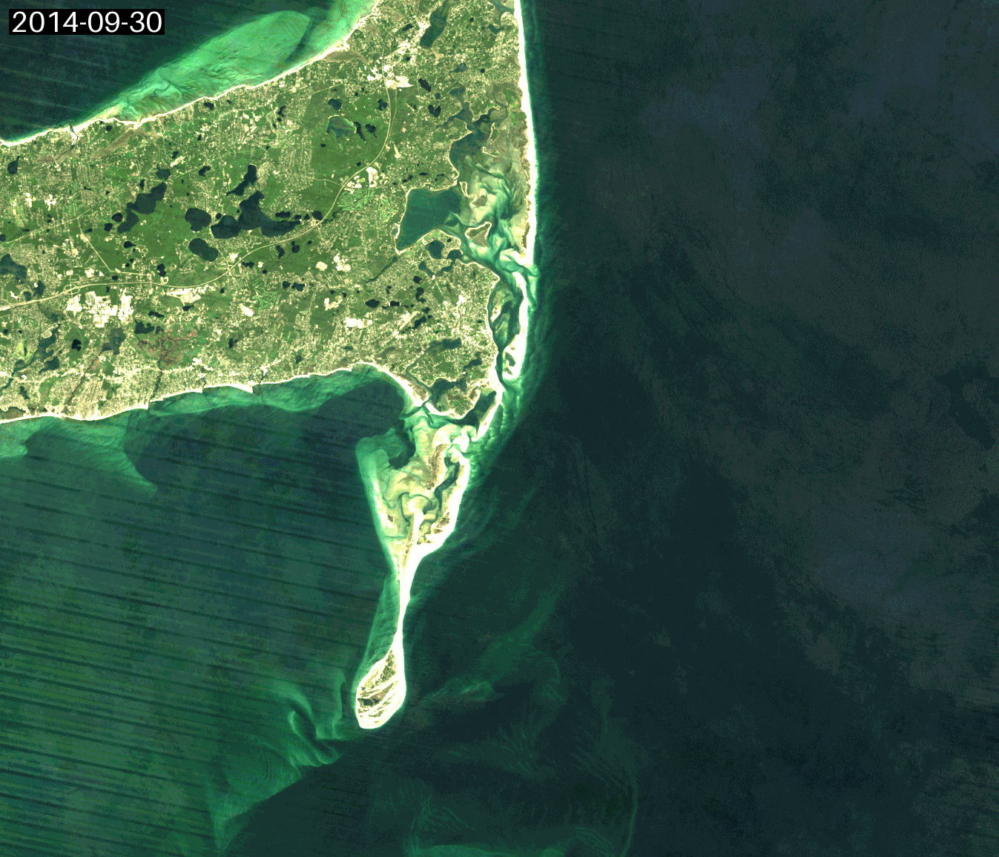

In [24]:
# Display GIF
landsat_gif

In [25]:
with open("cape_cod.gif", "wb") as f:
    f.write(landsat_gif.data)